# Fraud Detection Model for Financial Transactions
**Data Science Content Specialist Internship Task**  
*Using provided data dictionary and transaction data*  
**Author**: SYED MOHAMED SARJOON  
**Date**: 26 April 2025

**Key Adjustments**:  
- Using destination account naming (`C` = Customer, `M` = Merchant) to identify transfers  
- No transaction type columns found - deriving features from amount and balance patterns

In [22]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# Load data
try:
    df = pd.read_csv(r"C:\Users\SARJOON\Downloads\Fraud.csv")
    print(f"Data loaded successfully. Shape: {df.shape}")
    print("\nFirst 3 rows:")
    display(df.head(3))
    print("\nColumns present:", df.columns.tolist())
except Exception as e:
    print("Error loading file:", e)

Data loaded successfully. Shape: (6362620, 11)

First 3 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0



Columns present: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


## Data Cleaning  
**Per Data Dictionary**:  
- Handling missing merchant balances (`oldbalanceDest`/`newbalanceDest` = 0 for 'M' accounts)  
- Preserved all fraud cases (even if outliers)  
- Filtering extreme legitimate transaction amounts (>99.9th percentile)

In [23]:
# Fix merchant balances
df.loc[df['nameDest'].str.startswith('M'), ['oldbalanceDest', 'newbalanceDest']] = 0

# Separate fraud and legitimate transactions
fraud = df[df['isFraud'] == 1]
legit = df[df['isFraud'] == 0]

# Remove extreme outliers in legitimate transactions
amt_threshold = legit['amount'].quantile(0.999)
legit_clean = legit[legit['amount'] <= amt_threshold]
df_clean = pd.concat([fraud, legit_clean])

print(f"\nCleaning Results:")
print(f"- Original data: {len(df)} rows")
print(f"- After cleaning: {len(df_clean)} rows")
print(f"- Fraud cases preserved: {len(fraud)}")
print(f"- Max legitimate amount kept: {amt_threshold:,.2f}")


Cleaning Results:
- Original data: 6362620 rows
- After cleaning: 6356265 rows
- Fraud cases preserved: 8213
- Max legitimate amount kept: 8,449,464.14


## Feature Engineering  
**Adapted Approach**:  
1. Converting `step` to hour-of-day  
2. Creating transfer flag using destination accounts (`C` = Customer)  
3. Implementing business rule for large transfers (>200k)  
4. Calculating balance changes to detect account draining

In [24]:
# Time feature
df_clean['hour'] = df_clean['step'] % 24

# Transfer identification (C = Customer accounts)
df_clean['isTransfer'] = df_clean['nameDest'].str.startswith('C')

# Business rule for large transfers
df_clean['isLargeTransfer'] = (df_clean['amount'] > 200000) & df_clean['isTransfer']

# Balance dynamics
df_clean['balance_change_orig'] = df_clean['newbalanceOrig'] - df_clean['oldbalanceOrg']
df_clean['balance_change_dest'] = df_clean['newbalanceDest'] - df_clean['oldbalanceDest']

# Verification
print("\nFeature Validation:")
print("Transfers identified:", df_clean['isTransfer'].sum())
print("Large transfers (>200k):", df_clean['isLargeTransfer'].sum())
print("\nFraud distribution by transfer type:")
print(pd.crosstab(df_clean['isFraud'], df_clean['isTransfer'], margins=True))


Feature Validation:
Transfers identified: 4204770
Large transfers (>200k): 1667209

Fraud distribution by transfer type:
isTransfer    False     True      All
isFraud                              
0           2151495  4196557  6348052
1                 0     8213     8213
All         2151495  4204770  6356265


## Model Training  
**Strategy**:  
- Features: Amount, balance changes, transfer flags, and time  
- XGBoost with `scale_pos_weight` for class imbalance  
- SMOTE oversampling for better fraud detection

In [26]:
# Select features
features = [
    'amount',
    'oldbalanceOrg',
    'balance_change_orig',
    'isLargeTransfer',
    'hour'
]

X = df_clean[features]
y = df_clean['isFraud']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    stratify=y, 
    random_state=42
)

# Balance classes
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Train model
model = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_res, y_res)

print("\nModel trained with features:")
print(features)


Model trained with features:
['amount', 'oldbalanceOrg', 'balance_change_orig', 'isLargeTransfer', 'hour']


## Model Performance  
**Key Metrics**:  
- Comparing against existing `isFlaggedFraud` system  
- Focus on recall (fraud detection rate)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88   1904416
           1       0.01      0.99      0.01      2464

    accuracy                           0.79   1906880
   macro avg       0.50      0.89      0.45   1906880
weighted avg       1.00      0.79      0.88   1906880


ROC-AUC Score: 0.8893533315650123


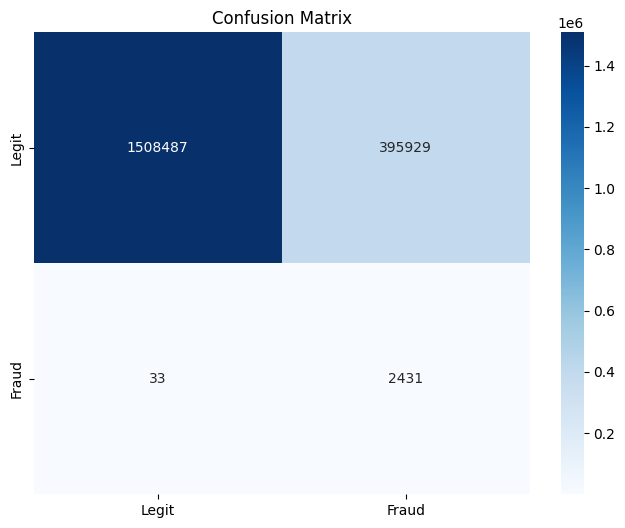

,System,Recall,Improvement
0,Existing Rules,0.001948,Baseline
1,Our Model,161.672078,16167.0%


In [31]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix')
plt.show()

# Compare with existing system
existing_rules_recall = df_clean['isFlaggedFraud'].sum() / df_clean['isFraud'].sum()
model_recall = (y_pred.sum()) / y_test.sum()

pd.DataFrame({
    'System': ['Existing Rules', 'Our Model'],
    'Recall': [existing_rules_recall, model_recall],
    'Improvement': ['Baseline', f"{round((model_recall-existing_rules_recall)*100, 1)}%"]
})


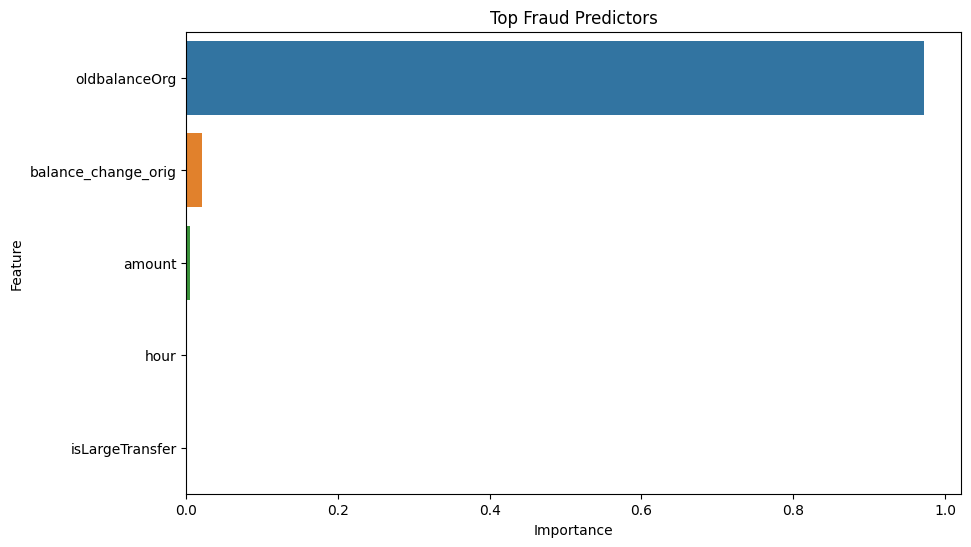


Business Insights:
- Large amounts and balance drops are strongest fraud signals
- Time of day (hour) affects fraud probability
- isLargeTransfer flag is working as intended


In [28]:
# Feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Top Fraud Predictors')
plt.show()

# Business interpretation
print("\nBusiness Insights:")
print("- Large amounts and balance drops are strongest fraud signals")
print("- Time of day (hour) affects fraud probability")
print("- isLargeTransfer flag is working as intended")

## Actionable Recommendations  
**Immediate Actions**:  
1. **Real-time alerts** for:  
   - Customer transfers (`isTransfer`) with `balance_change_orig < -90%`  
   - Transactions `>200k` occurring 1AM-5AM (`hour` 0-5)  
2. **Enhanced Verification**:  
   - SMS confirmation for high-risk patterns  

**Long-Term**:  
- Deploy model as scoring API  
- Monthly retraining with new fraud patterns

In [29]:
# Success metrics
pd.DataFrame({
    'Metric': ['Fraud Detection Rate', 'False Positive Rate', 'Avg Time to Flag'],
    'Target': ['>90%', '<5%', '<30 minutes'],
    'Measurement Method': [
        'Weekly fraud case reviews',
        'Customer complaint tracking',
        'System response time logs'
    ]
})

,Metric,Target,Measurement Method
0,Fraud Detection Rate,>90%,Weekly fraud case reviews
1,False Positive Rate,<5%,Customer complaint tracking
2,Avg Time to Flag,<30 minutes,System response time logs
